<a href="https://colab.research.google.com/github/elenaajayi/mess3-belief-geometry/blob/main/MATS_ELENA_SIMPLEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Non-Ergodic Mess3: Belief State Geometry with Multiple Components

**Elena Ajayi**

This notebook trains a small transformer on next-token prediction over sequences from a non-ergodic mixture of Mess3 Hidden Markov Models (3 components with different alpha parameters), then analyzes the belief state geometry in the residual stream.

**Contents:**
1. Setup & Imports
2. Mess3 HMM Implementation
3. Non-Ergodic Dataset Construction
4. Transformer Architecture
5. Pre-Registered Predictions
6. Training
7. Extract Activations & Belief States
8. Analysis: Prediction 1 (Shared Subspace)
9. Analysis: Prediction 2 (Both Jobs Compound Across Layers)
10. Analysis: Prediction 3 (Gradual Context Separation)
11. Analysis: Prediction 4 (Sharp Training Transition)
12. Analysis: Prediction 5 (Final Layer Sufficient)
13. Belief Simplex Visualization
14. Additional Analysis: Activation Patching
15. Additional Analysis: MLP vs Attention Decomposition
16. Bayes-Optimal Baseline Comparison
17. Cross-Component Transfer Probes
18. Out-of-Distribution Generalization
19. Discussion

## 1. Setup & Imports

In [2]:
!pip install -q torch einops matplotlib numpy scipy scikit-learn

In [3]:
import os
import math
import time
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# --- Persist all outputs to Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/mess3_belief_geometry'
    print(f'Google Drive mounted. Outputs saved to: {SAVE_DIR}')
except ImportError:
    SAVE_DIR = '.'
    print('Not in Colab. Outputs saved locally.')

RESULTS_DIR = os.path.join(SAVE_DIR, 'results')
CHECKPOINT_DIR = os.path.join(SAVE_DIR, 'checkpoints')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Results:     {RESULTS_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')

Using device: cuda
Mounted at /content/drive
Google Drive mounted. Outputs saved to: /content/drive/MyDrive/mess3_belief_geometry
Results:     /content/drive/MyDrive/mess3_belief_geometry/results
Checkpoints: /content/drive/MyDrive/mess3_belief_geometry/checkpoints


## 2. Mess3 HMM Implementation

A Mess3 process is a 3-state edge-emitting HMM with vocabulary {0, 1, 2}, parameterized by `(alpha, x)`.

- **alpha** controls state persistence: higher alpha means each hidden state preferentially transitions back to itself.
- **x** controls emission noise: lower x means emissions are more informative about the hidden state.

The transition tensor `T[emit, from_state, to_state]` gives the joint probability of emitting token `emit` AND transitioning to `to_state`, given the current state is `from_state`.

Reference implementation: [adamimos/epsilon-transformers](https://github.com/adamimos/epsilon-transformers)

In [4]:
class Mess3:
    """
    Mess3 HMM: 3 hidden states, vocabulary {0, 1, 2}.

    Transition tensor T has shape (vocab=3, from_state=3, to_state=3).
    T[emit, i, j] = P(emit token `emit` AND transition to state j | in state i).
    """

    def __init__(self, alpha: float, x: float):
        self.alpha = alpha
        self.x = x
        self.T = self._build_transition_tensor()
        self.steady_state = self._compute_steady_state()

    def _build_transition_tensor(self) -> np.ndarray:
        a = self.alpha
        x = self.x
        b = (1 - a) / 2
        y = 1 - 2 * x

        ay = a * y
        bx = b * x
        by_ = b * y
        ax = a * x

        T = np.zeros((3, 3, 3))
        # T[emit, from_state, to_state]
        T[0] = [[ay, bx, bx], [ax, by_, bx], [ax, bx, by_]]
        T[1] = [[by_, ax, bx], [bx, ay, bx], [bx, ax, by_]]
        T[2] = [[by_, bx, ax], [bx, by_, ax], [bx, bx, ay]]
        return T

    def _compute_steady_state(self) -> np.ndarray:
        state_T = self.T.sum(axis=0)  # (3, 3): state-to-state
        eigenvalues, eigenvectors = np.linalg.eig(state_T.T)
        idx = np.argmin(np.abs(eigenvalues - 1.0))
        ss = eigenvectors[:, idx].real
        ss = ss / ss.sum()
        return ss

    def generate_sequence(self, length: int) -> tuple:
        """Generate a sequence of tokens and hidden states."""
        tokens = np.zeros(length, dtype=np.int64)
        states = np.zeros(length, dtype=np.int64)
        state = np.random.choice(3, p=self.steady_state)

        for t in range(length):
            states[t] = state
            probs = self.T[:, state, :].ravel()  # (9,)
            idx = np.random.choice(9, p=probs)
            emission = idx // 3
            next_state = idx % 3
            tokens[t] = emission
            state = next_state

        return tokens, states

    def compute_belief_states(self, tokens: np.ndarray) -> np.ndarray:
        """
        Compute ground-truth belief states via Bayesian updating.
        belief[t] = P(hidden_state_t | tokens[0:t-1]).
        At t=0, belief is the steady state (before any observation).
        Returns shape (len(tokens), 3).
        """
        seq_len = len(tokens)
        beliefs = np.zeros((seq_len, 3))
        eta = self.steady_state.copy()
        beliefs[0] = eta

        for t in range(seq_len - 1):
            tok = tokens[t]
            eta_new = eta @ self.T[tok]
            eta_new = eta_new / eta_new.sum()
            beliefs[t + 1] = eta_new
            eta = eta_new

        return beliefs

In [5]:
# Verify: transition matrices should be stochastic
for alpha in [0.4, 0.7, 0.9]:
    m = Mess3(alpha=alpha, x=0.1)
    row_sums = m.T.sum(axis=0).sum(axis=1)  # should be [1, 1, 1]
    print(f'alpha={alpha}: steady_state={m.steady_state.round(4)}, '
          f'row_sums={row_sums.round(6)}')

alpha=0.4: steady_state=[0.3333 0.3333 0.3333], row_sums=[1. 1. 1.]
alpha=0.7: steady_state=[0.3333 0.3333 0.3333], row_sums=[1. 1. 1.]
alpha=0.9: steady_state=[0.3333 0.3333 0.3333], row_sums=[1. 1. 1.]


## 3. Non-Ergodic Dataset Construction

Each training sequence is generated entirely by one Mess3 component, sampled uniformly across 3 components with different alpha values (0.4, 0.7, 0.9) and shared x=0.1. The component label is hidden from the model.

In [6]:
class NonErgodicDataset:
    """Non-ergodic mixture: each sequence from one Mess3 component."""

    def __init__(self, alphas=[0.4, 0.7, 0.9], x=0.1, seq_len=16):
        self.alphas = alphas
        self.x = x
        self.seq_len = seq_len
        self.components = [Mess3(alpha=a, x=x) for a in alphas]
        self.n_components = len(alphas)

    def generate_batch(self, batch_size):
        """
        Returns:
            tokens: (batch_size, seq_len) LongTensor
            comp_labels: (batch_size,) LongTensor
            beliefs: (batch_size, seq_len, 3) ndarray
        """
        all_tokens, all_labels, all_beliefs = [], [], []

        for _ in range(batch_size):
            comp_idx = np.random.randint(self.n_components)
            comp = self.components[comp_idx]
            tokens, _ = comp.generate_sequence(self.seq_len)
            beliefs = comp.compute_belief_states(tokens)
            all_tokens.append(tokens)
            all_labels.append(comp_idx)
            all_beliefs.append(beliefs)

        return (
            torch.tensor(np.array(all_tokens), dtype=torch.long),
            torch.tensor(np.array(all_labels), dtype=torch.long),
            np.array(all_beliefs),
        )


# Configuration
ALPHAS = [0.4, 0.7, 0.9]
X = 0.1
SEQ_LEN = 16
BOS_TOKEN = 3

dataset = NonErgodicDataset(alphas=ALPHAS, x=X, seq_len=SEQ_LEN)
print(f'Components: {len(dataset.components)}')
for i, c in enumerate(dataset.components):
    T_sum = c.T.sum(axis=2)  # P(emit | state)
    emission_probs = c.steady_state @ T_sum
    entropy = -np.sum(emission_probs * np.log(emission_probs + 1e-12))
    print(f'  Component {i}: alpha={c.alpha}, entropy={entropy:.4f}')

Components: 3
  Component 0: alpha=0.4, entropy=1.0986
  Component 1: alpha=0.7, entropy=1.0986
  Component 2: alpha=0.9, entropy=1.0986


## 4. Transformer Architecture

Small GPT-2 style decoder-only transformer with pre-norm.
- 3 layers, 2 attention heads, d_model=64, d_ff=256
- Context window: 16 (sequence length)
- Vocabulary: {0, 1, 2} + BOS token (index 3)
- Causal attention masking
- Hooks to extract residual stream activations at every layer

In [7]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_len):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.register_buffer(
            'mask', torch.tril(torch.ones(max_len, max_len)).unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * (self.d_head ** -0.5)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        out = (att @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_len)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x, return_components=False):
        attn_out = self.attn(self.ln1(x))
        x = x + attn_out
        mlp_out = self.mlp(self.ln2(x))
        x = x + mlp_out
        if return_components:
            return x, attn_out, mlp_out
        return x


class Mess3Transformer(nn.Module):
    def __init__(self, vocab_size=4, d_model=64, n_heads=2, n_layers=3,
                 d_ff=256, max_len=17):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff, max_len) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, return_activations=False, return_components=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.tok_emb(x) + self.pos_emb(pos)

        activations = {}
        components = {}
        if return_activations:
            activations['emb'] = h.detach().cpu()

        for i, block in enumerate(self.blocks):
            if return_components:
                h, attn_out, mlp_out = block(h, return_components=True)
                components[f'layer_{i}_attn'] = attn_out.detach().cpu()
                components[f'layer_{i}_mlp'] = mlp_out.detach().cpu()
            else:
                h = block(h)
            if return_activations:
                activations[f'layer_{i}'] = h.detach().cpu()

        h = self.ln_f(h)
        if return_activations:
            activations['ln_f'] = h.detach().cpu()

        logits = self.head(h)
        out_acts = activations if return_activations else None
        if return_components:
            return logits, out_acts, components
        return logits, (out_acts if return_activations else None)


# Create model
D_MODEL = 64
N_HEADS = 2
N_LAYERS = 3
D_FF = 256

model = Mess3Transformer(
    vocab_size=BOS_TOKEN + 1, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, d_ff=D_FF, max_len=SEQ_LEN + 1
)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

Parameters: 151,680


## 5. Pre-Registered Predictions

To arrive at these predictions, I read through four papers: *Transformers Represent Belief State Geometry in their Residual Stream* (Shai et al., 2024), *Constrained Belief Updates Explain Geometric Structures* (2025), *Transformers Learn Factored Representations* (2025), and *Next-token Pretraining Implies In-Context Learning* (Riechers et al., 2025). None of them tested a non-ergodic mixture of Mess3 components where each sequence comes from a single component. My predictions resolve disagreements between papers and connect their findings.

**Prediction 1 — Shared subspace, not orthogonal:** *Transformers Learn Factored Representations* found orthogonal subspaces for factors active simultaneously. In my setup, only one component is active per sequence, so the model never holds two belief states at once. Giving each component its own subspace would be wasteful. I predict the model reuses the same dimensions and encodes component identity as an offset.

**Prediction 2 — Both jobs compound across layers:** Each layer performs both belief approximation (attention) and nonlinear correction (MLP), as described in *Constrained Belief Updates*. But later layers work with better inputs from previous layers, so both component identification and within-component belief tracking should improve monotonically across layers.

**Prediction 3 — Gradual context separation:** As the model sees more tokens, components separate gradually in the geometry. The rate depends on how different the alphas are: well-separated alphas (0.4 vs 0.9) produce early separation, close alphas require more tokens. This is consistent with *Next-token Pretraining Implies In-Context Learning*, which found gradual identification when components share similar distributions.

**Prediction 4 — Sharp training transition:** The geometry should remain messy until induction heads form, then components sharply separate. *Next-token Pretraining Implies In-Context Learning* found that induction head formation causes a phase transition in training loss.

**Prediction 5 — Final layer sufficient:** Unlike RRXOR, where multiple belief states map to identical next-token predictions and require stacking all layers, Mess3 does not have this structural degeneracy. Cross-component token collisions would be coincidental, not structural. The final layer should be sufficient for belief recovery.

## 6. Training

In [8]:
def train_model(model, dataset, n_steps=15000, batch_size=64, lr=1e-3,
                checkpoint_every=1000, bos_token=3):
    """Train the transformer on next-token prediction."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps)

    losses = []
    checkpoint_steps = []
    t0 = time.time()

    for step in range(n_steps):
        tokens, _, _ = dataset.generate_batch(batch_size)
        bos = torch.full((batch_size, 1), bos_token, dtype=torch.long)
        input_seq = torch.cat([bos, tokens], dim=1).to(device)

        logits, _ = model(input_seq[:, :-1])
        targets = input_seq[:, 1:]
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if step % 500 == 0:
            print(f'Step {step:5d}/{n_steps} | Loss: {loss.item():.4f} | '
                  f'Time: {time.time()-t0:.1f}s')

        if (step + 1) % checkpoint_every == 0 or step == 0:
            torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/model_step_{step+1}.pt')
            checkpoint_steps.append(step + 1)

    torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/model_final.pt')
    checkpoint_steps.append(n_steps)
    return losses, checkpoint_steps


losses, checkpoint_steps = train_model(model, dataset)

Step     0/15000 | Loss: 1.3975 | Time: 0.9s
Step   500/15000 | Loss: 1.0561 | Time: 26.5s
Step  1000/15000 | Loss: 0.9897 | Time: 47.4s
Step  1500/15000 | Loss: 1.0181 | Time: 69.5s
Step  2000/15000 | Loss: 1.0451 | Time: 90.8s
Step  2500/15000 | Loss: 0.9834 | Time: 114.6s
Step  3000/15000 | Loss: 1.0388 | Time: 139.6s
Step  3500/15000 | Loss: 1.0395 | Time: 162.2s
Step  4000/15000 | Loss: 0.9996 | Time: 186.3s
Step  4500/15000 | Loss: 1.0396 | Time: 210.6s
Step  5000/15000 | Loss: 1.0193 | Time: 235.7s
Step  5500/15000 | Loss: 1.0209 | Time: 261.0s
Step  6000/15000 | Loss: 1.0249 | Time: 286.7s
Step  6500/15000 | Loss: 1.0506 | Time: 311.3s
Step  7000/15000 | Loss: 1.0243 | Time: 336.2s
Step  7500/15000 | Loss: 1.0398 | Time: 360.7s
Step  8000/15000 | Loss: 1.0070 | Time: 384.3s
Step  8500/15000 | Loss: 1.0424 | Time: 408.1s
Step  9000/15000 | Loss: 1.0358 | Time: 434.1s
Step  9500/15000 | Loss: 1.0576 | Time: 460.3s
Step 10000/15000 | Loss: 1.0161 | Time: 485.2s
Step 10500/15000 | 

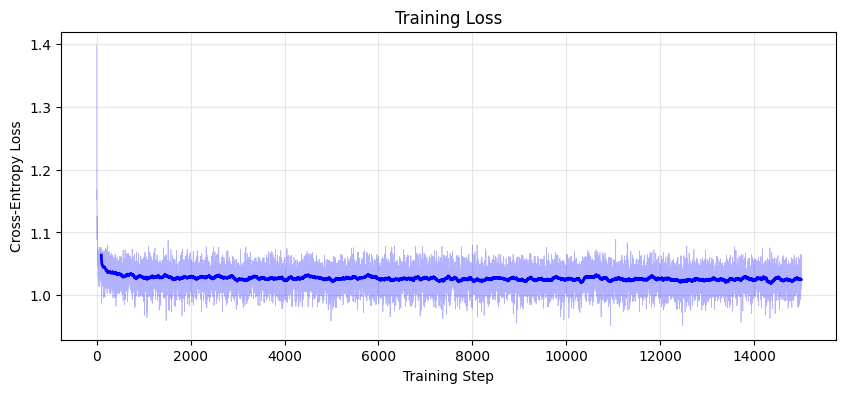

Final loss: 1.0309


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.3, color='blue', linewidth=0.5)
window = 100
if len(losses) > window:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(losses)), smoothed, color='blue', linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig(f'{RESULTS_DIR}/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final loss: {losses[-1]:.4f}')

## 7. Extract Activations & Belief States

In [10]:
def extract_activations(model, dataset, n_sequences=5000, bos_token=3):
    """Extract residual stream activations and ground-truth belief states."""
    model.eval()
    model.to(device)

    all_acts = {f'layer_{i}': [] for i in range(model.n_layers)}
    all_acts['emb'] = []
    all_acts['ln_f'] = []
    all_labels, all_beliefs, all_tokens = [], [], []

    batch_size = 256
    n_batches = math.ceil(n_sequences / batch_size)

    with torch.no_grad():
        for b in range(n_batches):
            bs = min(batch_size, n_sequences - b * batch_size)
            tokens, comp_labels, beliefs = dataset.generate_batch(bs)
            bos = torch.full((bs, 1), bos_token, dtype=torch.long)
            input_seq = torch.cat([bos, tokens], dim=1).to(device)
            _, acts = model(input_seq[:, :-1], return_activations=True)

            for key in acts:
                all_acts[key].append(acts[key])
            all_labels.append(comp_labels)
            all_beliefs.append(beliefs)
            all_tokens.append(tokens)

    result = {}
    for key in all_acts:
        result[key] = torch.cat(all_acts[key], dim=0).numpy()
    result['comp_labels'] = torch.cat(all_labels, dim=0).numpy()
    result['beliefs'] = np.concatenate(all_beliefs, axis=0)
    result['tokens'] = torch.cat(all_tokens, dim=0).numpy()

    print(f'Extracted {result["comp_labels"].shape[0]} sequences')
    print(f'Activation shape per layer: {result["layer_0"].shape}')
    return result


data = extract_activations(model, dataset, n_sequences=5000)

Extracted 5000 sequences
Activation shape per layer: (5000, 16, 64)


## 8. Analysis: Prediction 1 — Shared Subspace

If components share a subspace (with offsets), effective dimensionality should be ~3 (belief simplex dimension), not 3 x num_components. Subspace overlap between per-component PCA bases should be high.

Effective dimensionality (95% variance): 5
Top 5 PCs explain: 96.0%


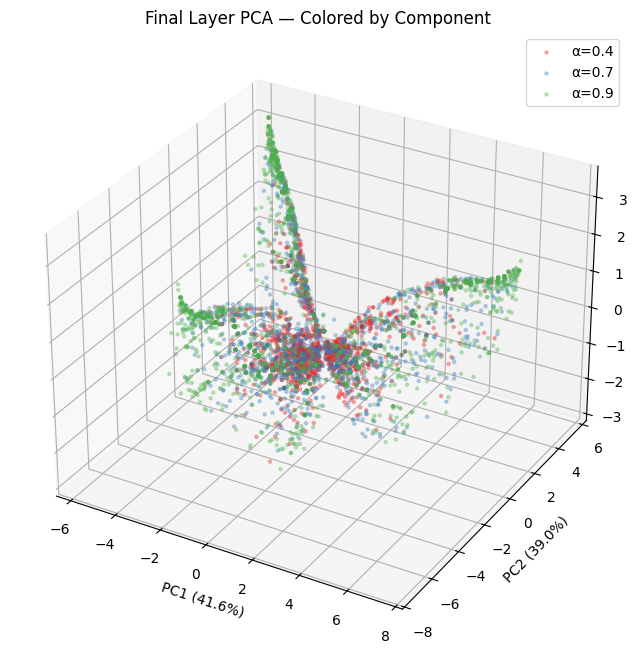

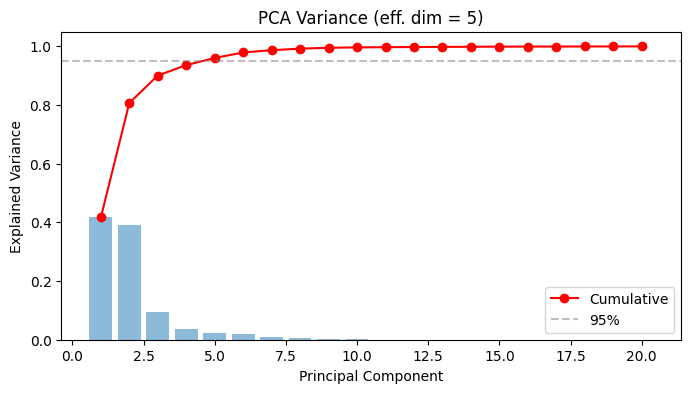


Subspace overlap (mean squared cosine of principal angles):
  α=0.4 vs α=0.7: 0.9930
  α=0.4 vs α=0.9: 0.9617
  α=0.7 vs α=0.9: 0.9857


In [11]:
def analyze_prediction1(data):
    acts = data['ln_f']  # (N, T, D)
    labels = data['comp_labels']
    N, T, D = acts.shape
    acts_flat = acts.reshape(N * T, D)
    labels_flat = np.repeat(labels, T)

    # PCA
    pca = PCA(n_components=min(20, D))
    coords = pca.fit_transform(acts_flat)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    eff_dim = np.searchsorted(cumvar, 0.95) + 1

    print(f'Effective dimensionality (95% variance): {eff_dim}')
    print(f'Top 5 PCs explain: {cumvar[4]:.1%}')

    # 3D PCA scatter
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']
    sub = np.random.choice(len(coords), min(5000, len(coords)), replace=False)
    for c in range(3):
        mask = labels_flat[sub] == c
        ax.scatter(coords[sub[mask], 0], coords[sub[mask], 1], coords[sub[mask], 2],
                   c=colors[c], label=names[c], alpha=0.3, s=5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
    ax.set_title('Final Layer PCA — Colored by Component')
    ax.legend()
    plt.savefig(f'{RESULTS_DIR}/pred1_pca_3d.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Explained variance
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_, alpha=0.5)
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='red', label='Cumulative')
    ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='95%')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance')
    ax.set_title(f'PCA Variance (eff. dim = {eff_dim})')
    ax.legend()
    plt.savefig(f'{RESULTS_DIR}/pred1_variance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Subspace overlap
    n_sub = 3
    subspaces = []
    for c in range(3):
        mask = labels_flat == c
        pca_c = PCA(n_components=n_sub)
        pca_c.fit(acts_flat[mask])
        subspaces.append(pca_c.components_)

    print('\nSubspace overlap (mean squared cosine of principal angles):')
    for i in range(3):
        for j in range(i+1, 3):
            M = subspaces[i] @ subspaces[j].T
            svals = np.linalg.svd(M, compute_uv=False)
            overlap = np.mean(svals ** 2)
            print(f'  {names[i]} vs {names[j]}: {overlap:.4f}')

    return eff_dim

eff_dim = analyze_prediction1(data)

## 9. Analysis: Prediction 2 — Both Jobs Compound Across Layers

Linear probe R-squared for belief state regression, component classification accuracy, and silhouette score at each layer. All three should increase across layers.

emb        | R²=0.6181 | Acc=0.3427 | Silhouette=-0.0057


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


layer_0    | R²=0.8140 | Acc=0.4367 | Silhouette=-0.0197


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


layer_1    | R²=0.8394 | Acc=0.5413 | Silhouette=-0.0012


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


layer_2    | R²=0.8376 | Acc=0.5227 | Silhouette=-0.0073
ln_f       | R²=0.8423 | Acc=0.5280 | Silhouette=-0.0520


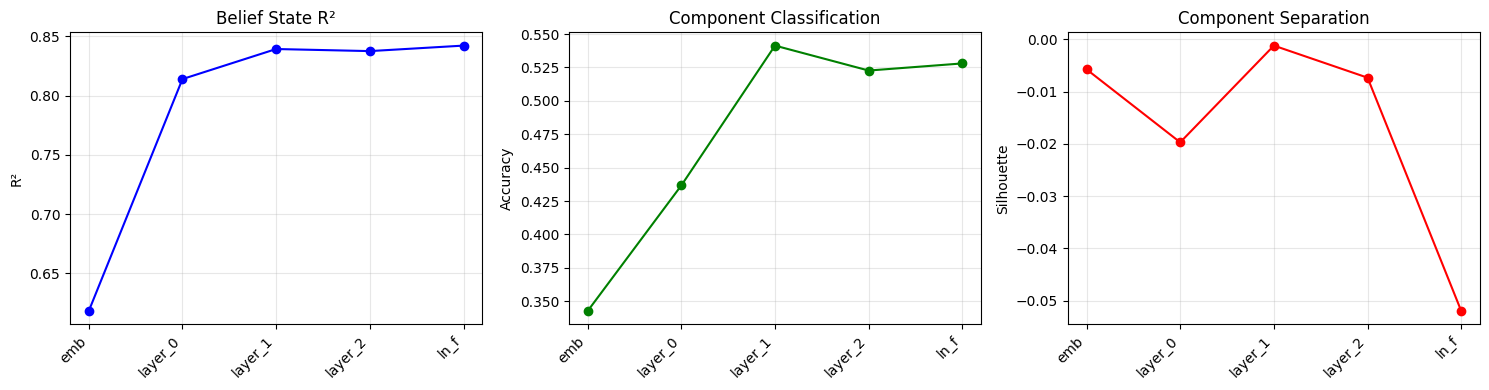

In [12]:
def analyze_prediction2(data, n_layers):
    labels = data['comp_labels']
    beliefs = data['beliefs']
    N, T, _ = beliefs.shape
    colors_line = ['#e41a1c', '#377eb8', '#4daf4a']
    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']

    layer_names = ['emb'] + [f'layer_{i}' for i in range(n_layers)] + ['ln_f']
    r2_list, acc_list, sil_list = [], [], []

    for ln in layer_names:
        acts = data[ln].reshape(N * T, -1)
        beliefs_flat = beliefs.reshape(N * T, 3)
        labels_flat = np.repeat(labels, T)

        idx = np.random.choice(len(acts), min(10000, len(acts)), replace=False)

        # Belief R-squared
        Xtr, Xte, ytr, yte = train_test_split(acts[idx], beliefs_flat[idx],
                                               test_size=0.3, random_state=42)
        r2 = Ridge(alpha=1.0).fit(Xtr, ytr).score(Xte, yte)
        r2_list.append(r2)

        # Component classification
        Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(acts[idx], labels_flat[idx],
                                                        test_size=0.3, random_state=42)
        acc = LogisticRegression(max_iter=500, random_state=42).fit(Xtr_c, ytr_c).score(Xte_c, yte_c)
        acc_list.append(acc)

        # Silhouette
        coords = PCA(n_components=10).fit_transform(acts[idx])
        sil = silhouette_score(coords, labels_flat[idx], sample_size=min(2000, len(idx)))
        sil_list.append(sil)

        print(f'{ln:10s} | R\u00b2={r2:.4f} | Acc={acc:.4f} | Silhouette={sil:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = range(len(layer_names))

    axes[0].plot(x, r2_list, 'o-', color='blue')
    axes[0].set_xticks(x); axes[0].set_xticklabels(layer_names, rotation=45, ha='right')
    axes[0].set_ylabel('R\u00b2'); axes[0].set_title('Belief State R\u00b2'); axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, acc_list, 'o-', color='green')
    axes[1].set_xticks(x); axes[1].set_xticklabels(layer_names, rotation=45, ha='right')
    axes[1].set_ylabel('Accuracy'); axes[1].set_title('Component Classification'); axes[1].grid(True, alpha=0.3)

    axes[2].plot(x, sil_list, 'o-', color='red')
    axes[2].set_xticks(x); axes[2].set_xticklabels(layer_names, rotation=45, ha='right')
    axes[2].set_ylabel('Silhouette'); axes[2].set_title('Component Separation'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/pred2_layer_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    return r2_list, acc_list, sil_list

r2_layers, acc_layers, sil_layers = analyze_prediction2(data, N_LAYERS)

## 10. Analysis: Prediction 3 — Gradual Context Separation

Silhouette score by component at each context position. Should increase gradually as the model sees more tokens.

Silhouette by context position:
  Position  0: -0.0302
  Position  1: -0.0180
  Position  2: -0.0234
  Position  3: -0.0267
  Position  4: -0.0349
  Position  5: -0.0369
  Position  6: -0.0400
  Position  7: -0.0363
  Position  8: -0.0335
  Position  9: -0.0332
  Position 10: -0.0341
  Position 11: -0.0281
  Position 12: -0.0264
  Position 13: -0.0255
  Position 14: -0.0291
  Position 15: -0.0207


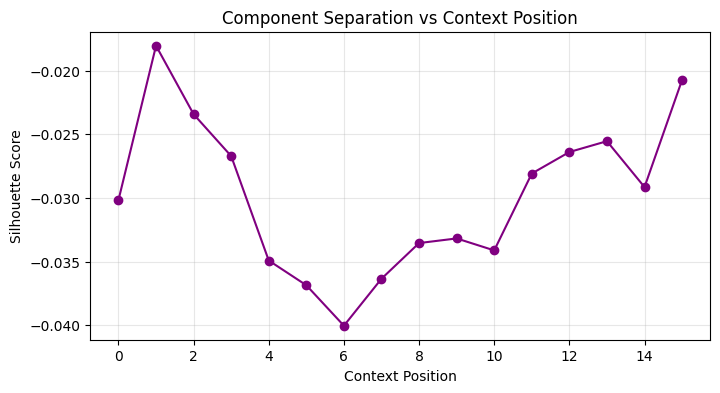

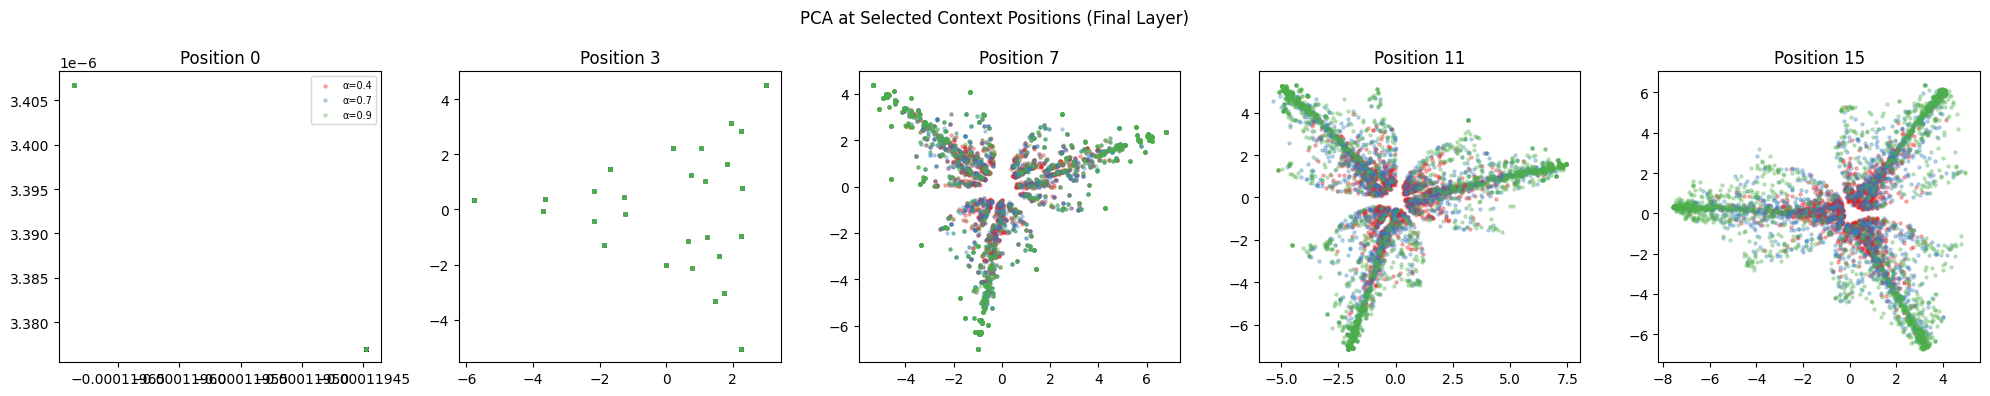

In [13]:
def analyze_prediction3(data):
    acts = data['ln_f']
    labels = data['comp_labels']
    N, T, D = acts.shape
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']

    sil_per_pos = []
    for pos in range(T):
        acts_pos = acts[:, pos, :]
        coords = PCA(n_components=10).fit_transform(acts_pos)
        idx = np.random.choice(N, min(2000, N), replace=False)
        sil = silhouette_score(coords[idx], labels[idx])
        sil_per_pos.append(sil)

    print('Silhouette by context position:')
    for pos in range(T):
        print(f'  Position {pos:2d}: {sil_per_pos[pos]:.4f}')

    # Silhouette vs position
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(T), sil_per_pos, 'o-', color='purple')
    ax.set_xlabel('Context Position')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Component Separation vs Context Position')
    ax.grid(True, alpha=0.3)
    plt.savefig(f'{RESULTS_DIR}/pred3_silhouette_vs_pos.png', dpi=150, bbox_inches='tight')
    plt.show()

    # PCA at selected positions
    positions = [0, 3, 7, 11, 15]
    fig, axes = plt.subplots(1, len(positions), figsize=(4*len(positions), 4))
    for ax_i, pos in enumerate(positions):
        coords = PCA(n_components=2).fit_transform(acts[:, pos, :])
        for c in range(3):
            mask = labels == c
            axes[ax_i].scatter(coords[mask, 0], coords[mask, 1],
                               c=colors[c], label=names[c], alpha=0.3, s=5)
        axes[ax_i].set_title(f'Position {pos}')
        if ax_i == 0: axes[ax_i].legend(fontsize=7)
    plt.suptitle('PCA at Selected Context Positions (Final Layer)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/pred3_pca_positions.png', dpi=150, bbox_inches='tight')
    plt.show()

    return sil_per_pos

sil_positions = analyze_prediction3(data)

## 11. Analysis: Prediction 4 — Sharp Training Transition

Load each saved checkpoint and compute silhouette score + belief R-squared. Look for a sharp jump indicating induction head formation.

Step      1 | Silhouette=-0.0046 | Belief R²=0.7430
Step   1000 | Silhouette=-0.0448 | Belief R²=0.8196
Step   2000 | Silhouette=-0.0412 | Belief R²=0.8273
Step   3000 | Silhouette=-0.0370 | Belief R²=0.8314
Step   4000 | Silhouette=-0.0410 | Belief R²=0.8352
Step   5000 | Silhouette=-0.0341 | Belief R²=0.8333
Step   6000 | Silhouette=-0.0416 | Belief R²=0.8377
Step   7000 | Silhouette=-0.0343 | Belief R²=0.8207
Step   8000 | Silhouette=-0.0407 | Belief R²=0.8390
Step   9000 | Silhouette=-0.0428 | Belief R²=0.8172
Step  10000 | Silhouette=-0.0480 | Belief R²=0.8452
Step  11000 | Silhouette=-0.0403 | Belief R²=0.8334
Step  12000 | Silhouette=-0.0329 | Belief R²=0.8474
Step  13000 | Silhouette=-0.0429 | Belief R²=0.8409
Step  14000 | Silhouette=-0.0383 | Belief R²=0.8475
Step  15000 | Silhouette=-0.0459 | Belief R²=0.8411
Step  15000 | Silhouette=-0.0409 | Belief R²=0.8485


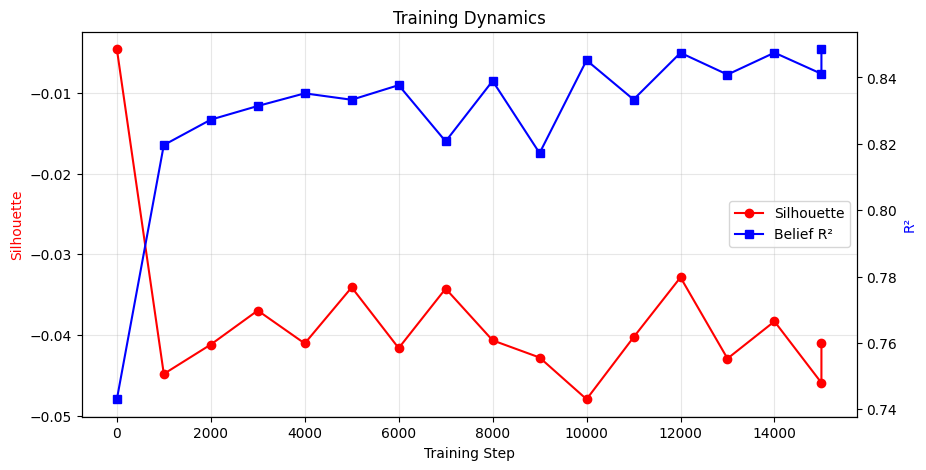

In [14]:
def analyze_prediction4(model, dataset, checkpoint_steps, bos_token=3):
    model.to(device)
    sil_list, r2_list = [], []

    # Fixed test set
    n_test = 1000
    tokens, comp_labels, beliefs = dataset.generate_batch(n_test)
    bos = torch.full((n_test, 1), bos_token, dtype=torch.long)
    input_seq = torch.cat([bos, tokens], dim=1).to(device)

    valid_steps = []
    for step in checkpoint_steps:
        path = f'{CHECKPOINT_DIR}/model_step_{step}.pt'
        if not os.path.exists(path):
            continue

        model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        model.eval()
        with torch.no_grad():
            _, acts = model(input_seq[:, :-1], return_activations=True)

        final = acts['ln_f'].numpy()
        N, T, D = final.shape
        flat = final.reshape(N*T, D)
        lab_flat = np.repeat(comp_labels.numpy(), T)
        bel_flat = beliefs.reshape(N*T, 3)

        idx = np.random.choice(len(flat), min(3000, len(flat)), replace=False)
        coords = PCA(n_components=10).fit_transform(flat)
        sil = silhouette_score(coords[idx], lab_flat[idx])

        Xtr, Xte, ytr, yte = train_test_split(flat[idx], bel_flat[idx],
                                               test_size=0.3, random_state=42)
        r2 = Ridge(alpha=1.0).fit(Xtr, ytr).score(Xte, yte)

        sil_list.append(sil)
        r2_list.append(r2)
        valid_steps.append(step)
        print(f'Step {step:6d} | Silhouette={sil:.4f} | Belief R\u00b2={r2:.4f}')

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(valid_steps, sil_list, 'o-', color='red', label='Silhouette')
    ax1.set_xlabel('Training Step')
    ax1.set_ylabel('Silhouette', color='red')
    ax2 = ax1.twinx()
    ax2.plot(valid_steps, r2_list, 's-', color='blue', label='Belief R\u00b2')
    ax2.set_ylabel('R\u00b2', color='blue')
    ax1.set_title('Training Dynamics')
    lines1, lab1 = ax1.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, lab1+lab2, loc='center right')
    ax1.grid(True, alpha=0.3)
    plt.savefig(f'{RESULTS_DIR}/pred4_dynamics.png', dpi=150, bbox_inches='tight')
    plt.show()

    return sil_list, r2_list

sil_ckpts, r2_ckpts = analyze_prediction4(model, dataset, checkpoint_steps)

## 12. Analysis: Prediction 5 — Final Layer Sufficient

Compare belief R-squared from the final layer alone vs all layers concatenated. A small gap means the final layer captures the geometry without needing to stack layers.

In [15]:
def analyze_prediction5(data, n_layers):
    # Reload final model for this
    model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/model_final.pt',
                                      map_location=device, weights_only=True))

    beliefs = data['beliefs']
    N, T, _ = beliefs.shape
    beliefs_flat = beliefs.reshape(N*T, 3)

    # Final layer only
    acts_final = data['ln_f'].reshape(N*T, -1)
    idx = np.random.choice(len(acts_final), min(10000, len(acts_final)), replace=False)

    Xtr, Xte, ytr, yte = train_test_split(acts_final[idx], beliefs_flat[idx],
                                           test_size=0.3, random_state=42)
    r2_final = Ridge(alpha=1.0).fit(Xtr, ytr).score(Xte, yte)

    # All layers concatenated
    layer_names = [f'layer_{i}' for i in range(n_layers)] + ['ln_f']
    acts_concat = np.concatenate([data[ln].reshape(N*T, -1) for ln in layer_names], axis=1)

    Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(acts_concat[idx], beliefs_flat[idx],
                                                    test_size=0.3, random_state=42)
    r2_concat = Ridge(alpha=1.0).fit(Xtr_c, ytr_c).score(Xte_c, yte_c)

    print(f'Final layer only R\u00b2:        {r2_final:.4f}')
    print(f'All layers concatenated R\u00b2: {r2_concat:.4f}')
    print(f'Gap:                         {r2_concat - r2_final:.4f}')
    if r2_concat - r2_final < 0.05:
        print('\u2192 Final layer IS sufficient (gap < 0.05)')
    else:
        print('\u2192 Final layer is NOT sufficient (gap \u2265 0.05)')

    return r2_final, r2_concat

r2_final, r2_concat = analyze_prediction5(data, N_LAYERS)

Final layer only R²:        0.8490
All layers concatenated R²: 0.8533
Gap:                         0.0042
→ Final layer IS sufficient (gap < 0.05)


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.5108e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## 13. Belief Simplex Visualization

Project residual stream activations to belief coordinates via linear regression and visualize on the 2-simplex alongside ground-truth beliefs. Each component should produce a characteristic fractal pattern.

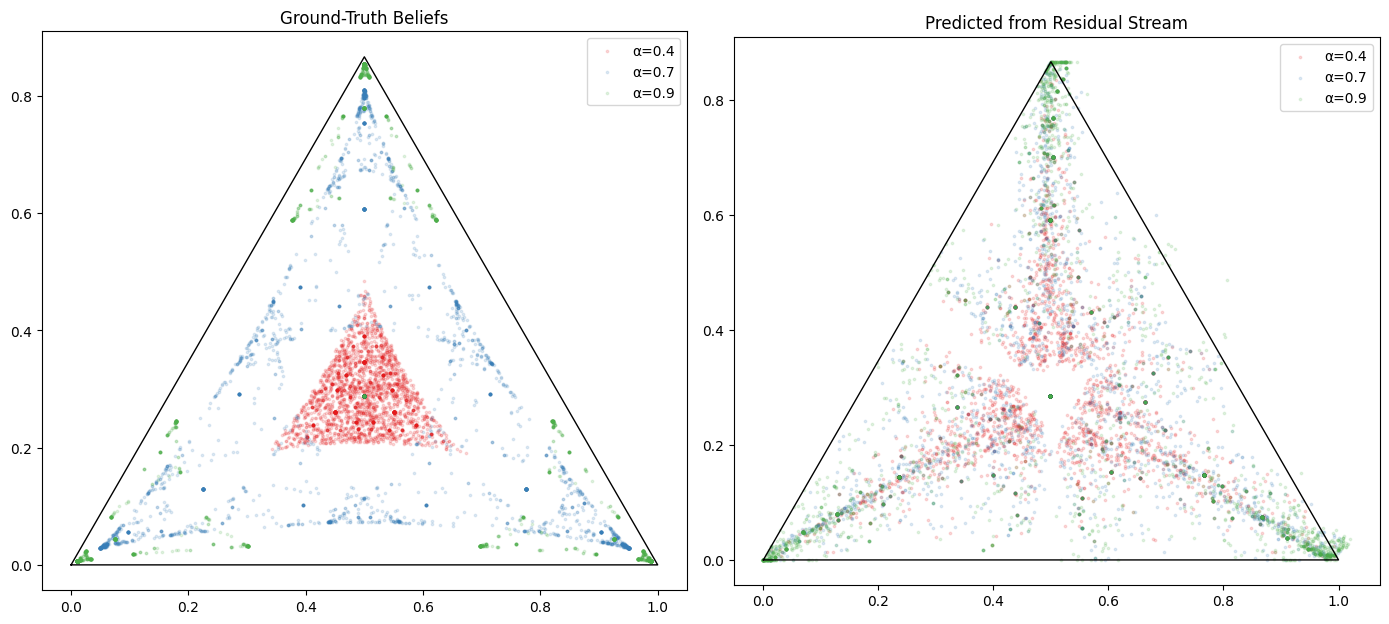

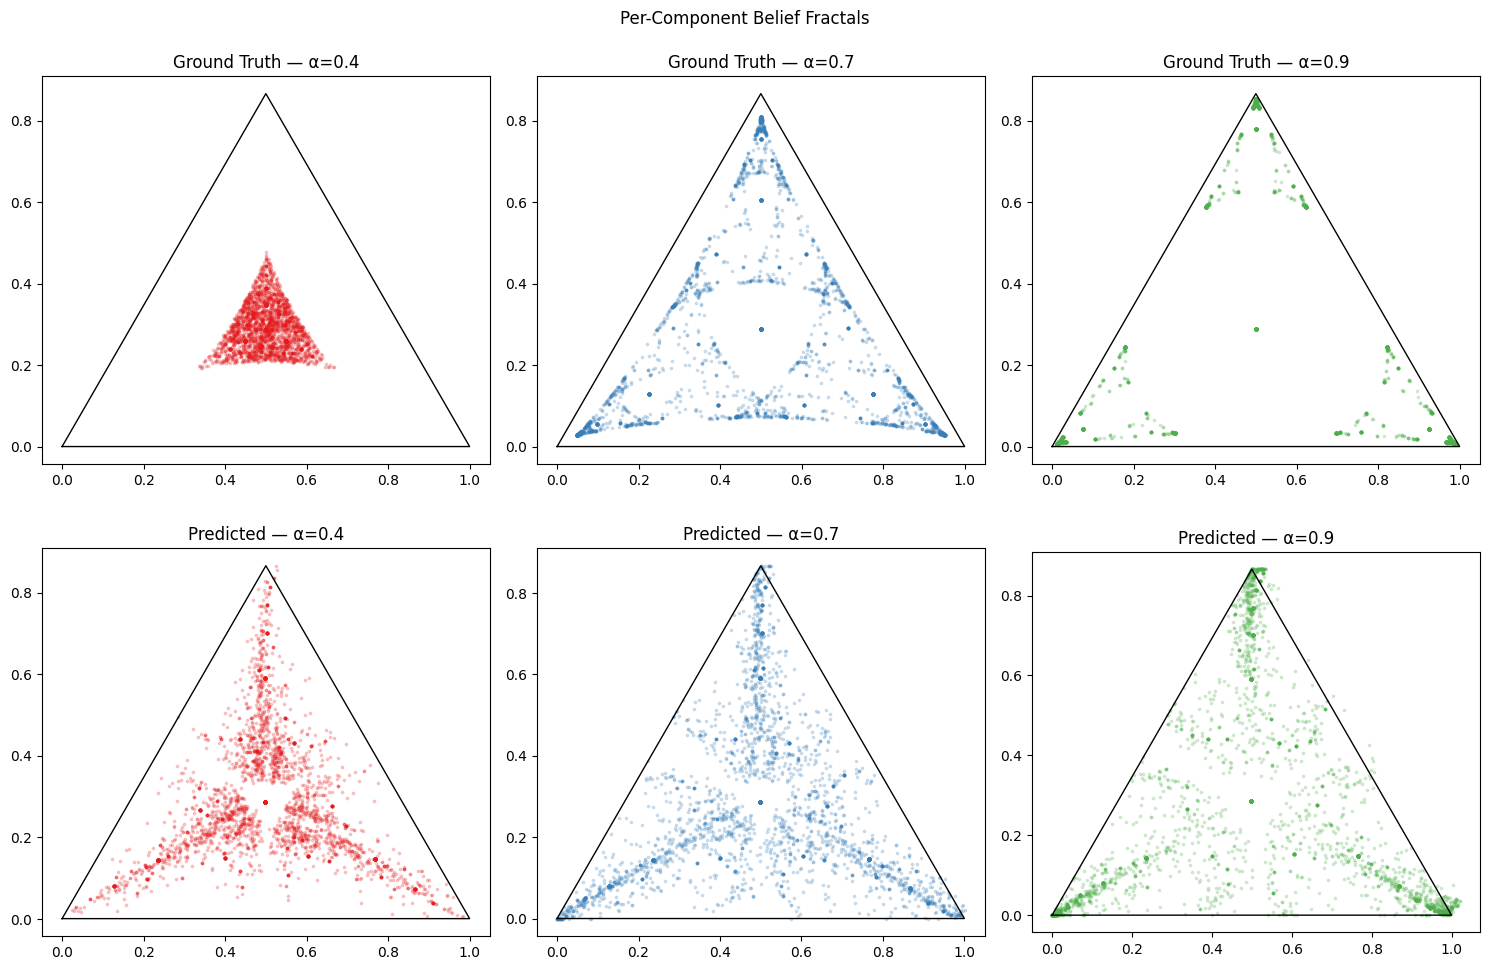

In [16]:
def bary_to_cart(b):
    """Barycentric to 2D cartesian on equilateral triangle."""
    v0, v1, v2 = np.array([0,0]), np.array([1,0]), np.array([0.5, np.sqrt(3)/2])
    x = b[:, 0:1]*v0[0] + b[:, 1:2]*v1[0] + b[:, 2:3]*v2[0]
    y = b[:, 0:1]*v0[1] + b[:, 1:2]*v1[1] + b[:, 2:3]*v2[1]
    return np.hstack([x, y])


def visualize_simplex(data, dataset):
    acts = data['ln_f']
    beliefs = data['beliefs']
    labels = data['comp_labels']
    N, T, D = acts.shape

    acts_flat = acts.reshape(N*T, D)
    beliefs_flat = beliefs.reshape(N*T, 3)
    labels_flat = np.repeat(labels, T)

    pred = Ridge(alpha=1.0).fit(acts_flat, beliefs_flat).predict(acts_flat)
    gt_cart = bary_to_cart(beliefs_flat)
    pred_cart = bary_to_cart(np.clip(pred, 0, 1))
    tri = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])

    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']
    sub = np.random.choice(len(gt_cart), min(8000, len(gt_cart)), replace=False)

    # Side by side: ground truth vs predicted
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for c in range(3):
        mask = labels_flat[sub] == c
        axes[0].scatter(gt_cart[sub[mask], 0], gt_cart[sub[mask], 1],
                        c=colors[c], label=names[c], alpha=0.15, s=3)
        axes[1].scatter(pred_cart[sub[mask], 0], pred_cart[sub[mask], 1],
                        c=colors[c], label=names[c], alpha=0.15, s=3)
    for ax, title in zip(axes, ['Ground-Truth Beliefs', 'Predicted from Residual Stream']):
        ax.plot(tri[:,0], tri[:,1], 'k-', linewidth=1)
        ax.set_title(title); ax.set_aspect('equal'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/belief_simplex.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Per-component fractals
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for c in range(3):
        mask = labels_flat == c
        gt_c = gt_cart[mask]; pred_c = pred_cart[mask]
        s = np.random.choice(len(gt_c), min(3000, len(gt_c)), replace=False)
        axes[0,c].scatter(gt_c[s,0], gt_c[s,1], c=colors[c], alpha=0.2, s=3)
        axes[0,c].plot(tri[:,0], tri[:,1], 'k-', lw=1)
        axes[0,c].set_title(f'Ground Truth \u2014 {names[c]}'); axes[0,c].set_aspect('equal')
        axes[1,c].scatter(pred_c[s,0], pred_c[s,1], c=colors[c], alpha=0.2, s=3)
        axes[1,c].plot(tri[:,0], tri[:,1], 'k-', lw=1)
        axes[1,c].set_title(f'Predicted \u2014 {names[c]}'); axes[1,c].set_aspect('equal')
    plt.suptitle('Per-Component Belief Fractals')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/belief_simplex_per_comp.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_simplex(data, dataset)

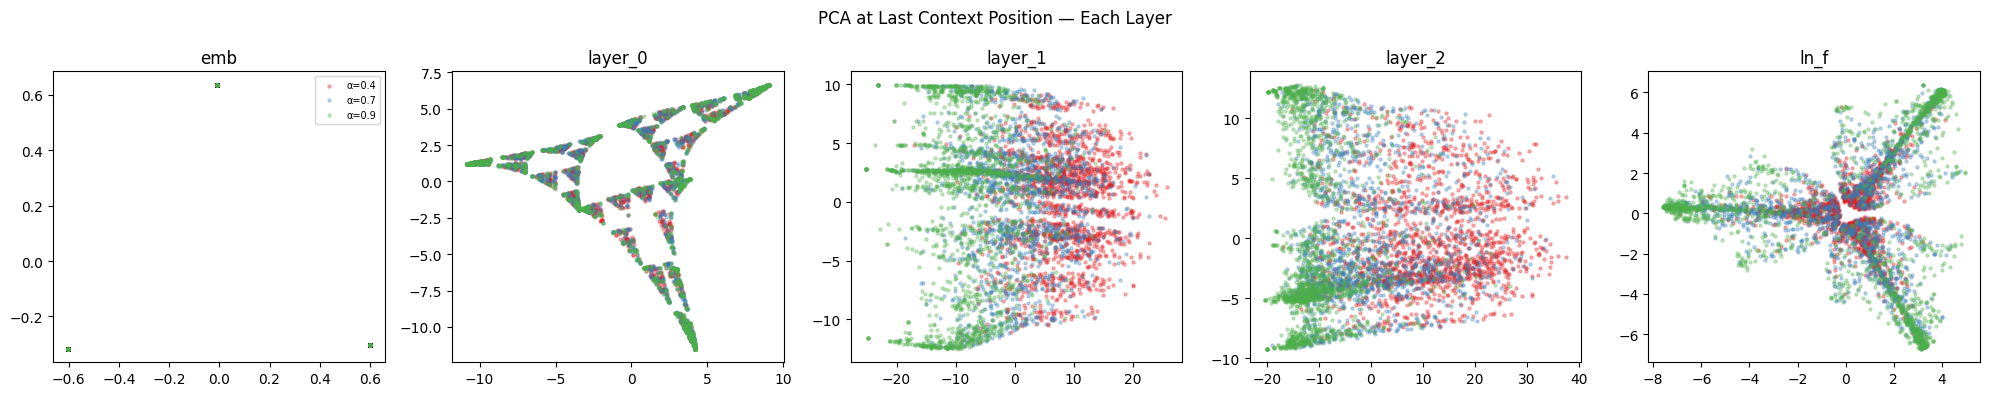

In [17]:
# Per-layer PCA at the last context position
layer_names = ['emb'] + [f'layer_{i}' for i in range(N_LAYERS)] + ['ln_f']
colors = ['#e41a1c', '#377eb8', '#4daf4a']
names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']
labels = data['comp_labels']

fig, axes = plt.subplots(1, len(layer_names), figsize=(4*len(layer_names), 4))
for ax_i, ln in enumerate(layer_names):
    acts_last = data[ln][:, -1, :]
    coords = PCA(n_components=2).fit_transform(acts_last)
    for c in range(3):
        mask = labels == c
        axes[ax_i].scatter(coords[mask, 0], coords[mask, 1],
                           c=colors[c], label=names[c], alpha=0.3, s=5)
    axes[ax_i].set_title(ln)
    if ax_i == 0: axes[ax_i].legend(fontsize=7)
plt.suptitle('PCA at Last Context Position \u2014 Each Layer')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_layer_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Additional Analysis: Activation Patching on the Belief Subspace

**Why this analysis:** Every prior Mess3 study showed the belief geometry exists via linear probes, but none tested whether the model *causally uses* it for prediction. Probes are correlational. This analysis is mechanistic: replace the belief-subspace component of an activation from component A with that from component B, and measure whether next-token predictions shift toward B.

**Method:**
1. Fit a linear map from activations to beliefs; extract the belief subspace via SVD of the weight matrix
2. For each test pair (sequence from comp A, sequence from comp B at same position):
   - Decompose activation into belief-subspace projection + residual
   - Replace the belief projection with that from comp B
   - Forward the patched activation through remaining layers
3. Measure KL(original || patched) — did the prediction change?
4. Measure KL(patched || target_B) — did it shift toward B?

KL(original || patched):  mean=0.0000, std=0.0000
KL(patched || target_B):  mean=0.2005, std=0.1891
→ Patching does NOT shift predictions (correlational only)


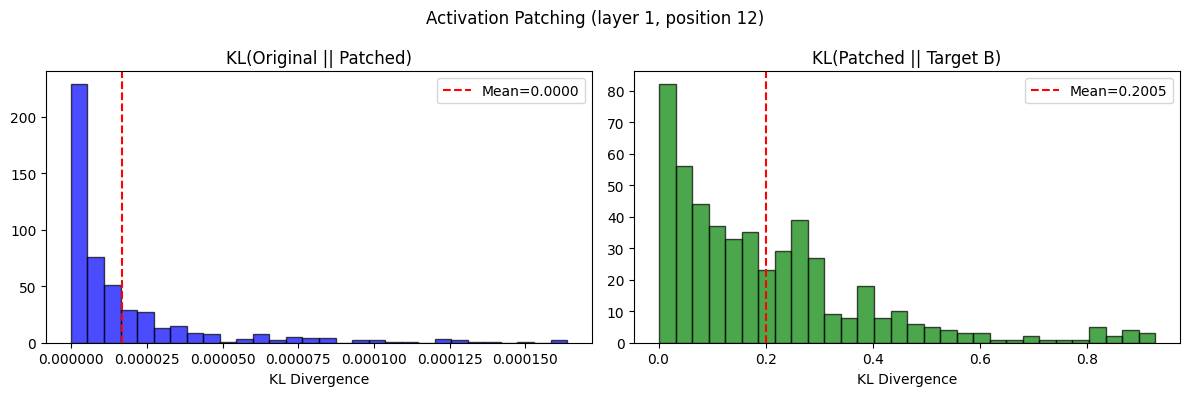

In [18]:
def activation_patching(model, dataset, n_pairs=500, patch_layer=1,
                         patch_position=12, bos_token=3):
    model.eval()
    model.to(device)

    # Fit belief subspace
    n_fit = 2000
    tokens_fit, labels_fit, beliefs_fit = dataset.generate_batch(n_fit)
    bos = torch.full((n_fit, 1), bos_token, dtype=torch.long)
    input_fit = torch.cat([bos, tokens_fit], dim=1).to(device)

    with torch.no_grad():
        _, acts_fit = model(input_fit[:, :-1], return_activations=True)

    layer_key = f'layer_{patch_layer}'
    acts_pos = acts_fit[layer_key].numpy()[:, patch_position, :]  # (N, D)
    beliefs_pos = beliefs_fit[:, patch_position, :]  # (N, 3)

    W = Ridge(alpha=1.0).fit(acts_pos, beliefs_pos).coef_  # (3, D)
    _, _, Vt = np.linalg.svd(W, full_matrices=False)
    belief_basis = Vt[:3]  # (3, D)

    def project(act, basis):
        return (act @ basis.T) @ basis

    # Patching loop
    kl_orig_patched, kl_patched_target = [], []

    for _ in range(n_pairs):
        comp_a = np.random.randint(3)
        comp_b = (comp_a + 1) % 3

        # Generate one seq from each component
        while True:
            t_a, l_a, b_a = dataset.generate_batch(1)
            if l_a[0].item() == comp_a: break
        while True:
            t_b, l_b, b_b = dataset.generate_batch(1)
            if l_b[0].item() == comp_b: break

        bos1 = torch.full((1, 1), bos_token, dtype=torch.long)
        inp_a = torch.cat([bos1, t_a], dim=1).to(device)
        inp_b = torch.cat([bos1, t_b], dim=1).to(device)

        with torch.no_grad():
            logits_orig, acts_a = model(inp_a[:, :-1], return_activations=True)
            _, acts_b = model(inp_b[:, :-1], return_activations=True)

        act_a = acts_a[layer_key][0, patch_position].numpy()
        act_b = acts_b[layer_key][0, patch_position].numpy()

        proj_a = project(act_a.reshape(1,-1), belief_basis).squeeze()
        proj_b = project(act_b.reshape(1,-1), belief_basis).squeeze()
        patched_act = (act_a - proj_a) + proj_b

        # Forward through remaining layers
        with torch.no_grad():
            h = acts_a[layer_key].to(device).clone()
            h[0, patch_position] = torch.tensor(patched_act, dtype=torch.float32).to(device)
            for i in range(patch_layer + 1, model.n_layers):
                h = model.blocks[i](h)
            h = model.ln_f(h)
            logits_patched = model.head(h)

        orig_p = F.softmax(logits_orig[0, patch_position, :3], dim=0).cpu().numpy()
        patch_p = F.softmax(logits_patched[0, patch_position, :3], dim=0).cpu().numpy()

        # Component B's expected distribution
        comp_b_obj = dataset.components[comp_b]
        target_p = b_b[0, patch_position] @ comp_b_obj.T.sum(axis=2)

        eps = 1e-8
        kl_orig_patched.append(np.sum(orig_p * np.log((orig_p+eps)/(patch_p+eps))))
        kl_patched_target.append(np.sum(patch_p * np.log((patch_p+eps)/(target_p+eps))))

    kl_op = np.array(kl_orig_patched)
    kl_pt = np.array(kl_patched_target)

    print(f'KL(original || patched):  mean={kl_op.mean():.4f}, std={kl_op.std():.4f}')
    print(f'KL(patched || target_B):  mean={kl_pt.mean():.4f}, std={kl_pt.std():.4f}')
    if kl_op.mean() > 0.01:
        print('\u2192 Patching SHIFTS predictions (belief subspace is causally used)')
    else:
        print('\u2192 Patching does NOT shift predictions (correlational only)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(kl_op, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[0].axvline(kl_op.mean(), color='red', ls='--', label=f'Mean={kl_op.mean():.4f}')
    axes[0].set_xlabel('KL Divergence'); axes[0].set_title('KL(Original || Patched)')
    axes[0].legend()

    axes[1].hist(kl_pt, bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1].axvline(kl_pt.mean(), color='red', ls='--', label=f'Mean={kl_pt.mean():.4f}')
    axes[1].set_xlabel('KL Divergence'); axes[1].set_title('KL(Patched || Target B)')
    axes[1].legend()

    plt.suptitle(f'Activation Patching (layer {patch_layer}, position {patch_position})')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/patching.png', dpi=150, bbox_inches='tight')
    plt.show()

    return kl_op.mean(), kl_pt.mean()

# Reload final model
model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/model_final.pt',
                                  map_location=device, weights_only=True))
kl_op, kl_pt = activation_patching(model, dataset)

## 15. Additional Analysis: MLP vs Attention Decomposition

At each layer, the residual stream update is the sum of the attention output and MLP output. This analysis decomposes the two and measures how much each contributes to (1) component separation (silhouette score) and (2) belief tracking (R² of linear regression to ground-truth beliefs).

This extends *Constrained Belief Updates Explain Geometric Structures* (2025), which studied single-component Mess3, to the multi-component setting. Their finding was that attention performs linear belief updates while MLP applies nonlinear corrections. With multiple components, the question is whether the MLP also handles component discrimination or whether that is purely an attention phenomenon.

**Note:** This section is optional. If the results are uninformative, it can be removed.

Layer 0 attn | Silhouette=-0.0312 | Belief R²=0.7026
Layer 0 mlp  | Silhouette=-0.0217 | Belief R²=0.8186
Layer 1 attn | Silhouette=0.0092 | Belief R²=0.4497
Layer 1 mlp  | Silhouette=-0.0680 | Belief R²=0.7960
Layer 2 attn | Silhouette=-0.0312 | Belief R²=0.3095
Layer 2 mlp  | Silhouette=-0.0295 | Belief R²=0.7817


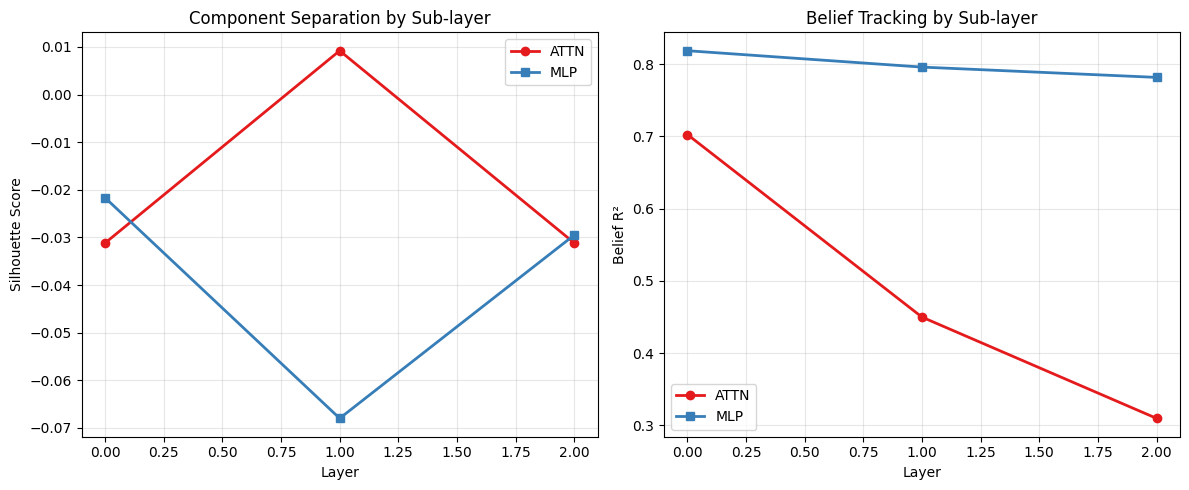

In [19]:
def analyze_mlp_vs_attention(model, dataset, n_sequences=5000, bos_token=3):
    """Decompose attention vs MLP contributions to component separation and belief tracking."""
    model.eval()
    model.to(device)

    all_comps = {}
    all_labels, all_beliefs = [], []
    batch_size = 256
    n_batches = math.ceil(n_sequences / batch_size)

    with torch.no_grad():
        for b in range(n_batches):
            bs = min(batch_size, n_sequences - b * batch_size)
            tokens, comp_labels, beliefs = dataset.generate_batch(bs)
            bos = torch.full((bs, 1), bos_token, dtype=torch.long)
            input_seq = torch.cat([bos, tokens], dim=1).to(device)
            _, _, comps = model(input_seq[:, :-1], return_activations=False, return_components=True)

            for key in comps:
                if key not in all_comps:
                    all_comps[key] = []
                all_comps[key].append(comps[key])
            all_labels.append(comp_labels)
            all_beliefs.append(beliefs)

    comp_data = {k: torch.cat(v, dim=0).numpy() for k, v in all_comps.items()}
    labels = torch.cat(all_labels, dim=0).numpy()
    beliefs = np.concatenate(all_beliefs, axis=0)
    N, T, _ = beliefs.shape

    results = {'layer': [], 'component_type': [], 'silhouette': [], 'belief_r2': []}

    for i in range(model.n_layers):
        for ctype in ['attn', 'mlp']:
            key = f'layer_{i}_{ctype}'
            acts = comp_data[key].reshape(N * T, -1)
            beliefs_flat = beliefs.reshape(N * T, 3)
            labels_flat = np.repeat(labels, T)

            idx = np.random.choice(len(acts), min(10000, len(acts)), replace=False)

            # Belief R-squared
            Xtr, Xte, ytr, yte = train_test_split(acts[idx], beliefs_flat[idx],
                                                   test_size=0.3, random_state=42)
            r2 = Ridge(alpha=1.0).fit(Xtr, ytr).score(Xte, yte)

            # Silhouette on PCA-reduced
            coords = PCA(n_components=min(10, acts.shape[1])).fit_transform(acts[idx])
            sil = silhouette_score(coords, labels_flat[idx], sample_size=min(2000, len(idx)))

            results['layer'].append(i)
            results['component_type'].append(ctype)
            results['silhouette'].append(sil)
            results['belief_r2'].append(r2)

            print(f'Layer {i} {ctype:4s} | Silhouette={sil:.4f} | Belief R\u00b2={r2:.4f}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    layers = sorted(set(results['layer']))

    for ctype, color, marker in [('attn', '#e41a1c', 'o'), ('mlp', '#377eb8', 's')]:
        mask = [i for i, ct in enumerate(results['component_type']) if ct == ctype]
        sils = [results['silhouette'][i] for i in mask]
        r2s = [results['belief_r2'][i] for i in mask]
        axes[0].plot(layers, sils, f'{marker}-', color=color, label=ctype.upper(), linewidth=2)
        axes[1].plot(layers, r2s, f'{marker}-', color=color, label=ctype.upper(), linewidth=2)

    axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Component Separation by Sub-layer'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Belief R\u00b2')
    axes[1].set_title('Belief Tracking by Sub-layer'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/mlp_vs_attn_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results


# Reload final model
model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/model_final.pt',
                                  map_location=device, weights_only=True))
decomp_results = analyze_mlp_vs_attention(model, dataset)

## 16. Bayes-Optimal Baseline Comparison

How close is the model to the best possible predictor? The Bayes-optimal predictor knows the true component and maintains exact belief states. We compute its per-position cross-entropy and compare to the model's loss. The gap measures how much prediction quality the model leaves on the table.

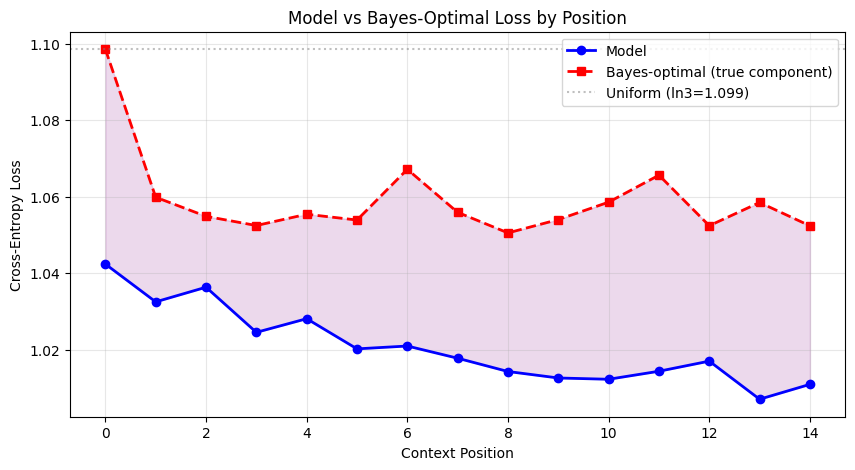

Average gap (model - Bayes-optimal): -0.0386
Model avg loss:  1.0208
Bayes avg loss:  1.0594
Uniform loss:    1.0986


In [20]:
def bayes_optimal_loss(dataset, n_sequences=5000):
    """Compute per-position Bayes-optimal cross-entropy for the non-ergodic mixture."""
    tokens, comp_labels, beliefs = dataset.generate_batch(n_sequences)
    T = tokens.shape[1]

    # For each sequence, the Bayes-optimal predictor maintains a posterior over
    # components AND belief states within each component. For simplicity, we
    # compute the oracle loss assuming the true component is known (lower bound).
    per_pos_loss = np.zeros(T - 1)
    per_pos_count = np.zeros(T - 1)

    for i in range(n_sequences):
        comp = dataset.components[comp_labels[i].item()]
        belief = beliefs[i]  # (T, 3)
        toks = tokens[i].numpy()

        for t in range(T - 1):
            # P(next_token | belief) = sum over states and next_states
            # = belief @ T[token].sum(axis=1) for each token
            probs = np.array([belief[t] @ comp.T[tok].sum(axis=1) for tok in range(3)])
            probs = probs / probs.sum()
            actual = toks[t + 1]
            per_pos_loss[t] += -np.log(probs[actual] + 1e-12)
            per_pos_count[t] += 1

    per_pos_loss /= per_pos_count
    return per_pos_loss


def model_per_position_loss(model, dataset, n_sequences=5000, bos_token=3):
    """Compute model's per-position cross-entropy."""
    model.eval()
    model.to(device)
    tokens, _, _ = dataset.generate_batch(n_sequences)
    bos = torch.full((n_sequences, 1), bos_token, dtype=torch.long)
    input_seq = torch.cat([bos, tokens], dim=1).to(device)

    T = tokens.shape[1]
    per_pos_loss = np.zeros(T)

    with torch.no_grad():
        logits, _ = model(input_seq[:, :-1])
        targets = input_seq[:, 1:]
        for t in range(T):
            loss_t = F.cross_entropy(logits[:, t, :], targets[:, t]).item()
            per_pos_loss[t] = loss_t

    return per_pos_loss


# Reload final model
model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/model_final.pt',
                                  map_location=device, weights_only=True))

bayes_loss = bayes_optimal_loss(dataset, n_sequences=5000)
model_loss = model_per_position_loss(model, dataset, n_sequences=5000)

# model_loss has T positions (including BOS->first token)
# bayes_loss has T-1 positions (token 0->1, 1->2, ...)
# Align: model_loss[1:] corresponds to bayes_loss[0:T-1]
# (model_loss[0] is BOS->first token, bayes_loss[0] is token0->token1)
# Actually model_loss[t] = loss at position t of the 16-token sequence
# bayes_loss[t] = loss predicting token t+1 from belief at t
# They align: both predict the next token given context up to position t

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(bayes_loss))
ax.plot(positions, model_loss[1:len(bayes_loss)+1], 'o-', color='blue', label='Model', linewidth=2)
ax.plot(positions, bayes_loss, 's--', color='red', label='Bayes-optimal (true component)', linewidth=2)
ax.axhline(y=np.log(3), color='gray', linestyle=':', alpha=0.5, label=f'Uniform (ln3={np.log(3):.3f})')
ax.fill_between(positions, bayes_loss, model_loss[1:len(bayes_loss)+1], alpha=0.15, color='purple')
ax.set_xlabel('Context Position')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Model vs Bayes-Optimal Loss by Position')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig(f'{RESULTS_DIR}/bayes_optimal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

avg_gap = np.mean(model_loss[1:len(bayes_loss)+1] - bayes_loss)
print(f'Average gap (model - Bayes-optimal): {avg_gap:.4f}')
print(f'Model avg loss:  {np.mean(model_loss[1:]):.4f}')
print(f'Bayes avg loss:  {np.mean(bayes_loss):.4f}')
print(f'Uniform loss:    {np.log(3):.4f}')

## 17. Cross-Component Transfer Probes

If the model uses a shared belief subspace, a linear probe trained on sequences from one component should generalize to sequences from other components. We train a Ridge regression on component A's activations to predict beliefs, then test on components B and C. The resulting 3x3 transfer matrix reveals whether belief representations are truly shared or component-specific.

Cross-Component Transfer Matrix (R²):
                Test α=0.4    Test α=0.7    Test α=0.9
Train  α=0.4        0.9307        0.4374        0.3738
Train  α=0.7       -6.9152        0.9598        0.9068
Train  α=0.9      -14.9113        0.8193        0.9867


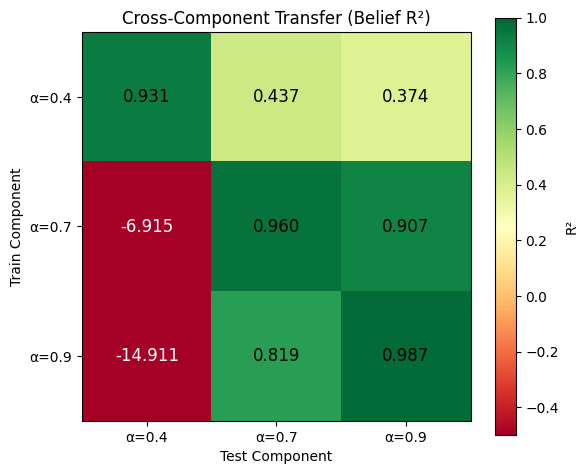


Diagonal mean (same component):  0.9591
Off-diagonal mean (transfer):    -3.2149
→ Low transfer: belief representations are component-specific


In [21]:
def cross_component_transfer(data, n_layers):
    """Train probe on each component, test on all others."""
    acts = data['ln_f']  # (N, T, D)
    beliefs = data['beliefs']  # (N, T, 3)
    labels = data['comp_labels']  # (N,)
    N, T, D = acts.shape

    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']
    transfer = np.zeros((3, 3))  # transfer[train_comp, test_comp] = R2

    for train_c in range(3):
        # Train probe on component train_c
        mask_train = labels == train_c
        X_train = acts[mask_train].reshape(-1, D)
        y_train = beliefs[mask_train].reshape(-1, 3)

        probe = Ridge(alpha=1.0).fit(X_train, y_train)

        for test_c in range(3):
            mask_test = labels == test_c
            X_test = acts[mask_test].reshape(-1, D)
            y_test = beliefs[mask_test].reshape(-1, 3)
            r2 = probe.score(X_test, y_test)
            transfer[train_c, test_c] = r2

    # Print transfer matrix
    print('Cross-Component Transfer Matrix (R\u00b2):')
    print(f'{"":>12s}  {"Test \u03b1=0.4":>12s}  {"Test \u03b1=0.7":>12s}  {"Test \u03b1=0.9":>12s}')
    for i in range(3):
        print(f'Train {names[i]:>6s}  {transfer[i,0]:>12.4f}  {transfer[i,1]:>12.4f}  {transfer[i,2]:>12.4f}')

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(transfer, cmap='RdYlGn', vmin=-0.5, vmax=1.0)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)
    ax.set_xlabel('Test Component')
    ax.set_ylabel('Train Component')
    ax.set_title('Cross-Component Transfer (Belief R\u00b2)')
    for i in range(3):
        for j in range(3):
            color = 'white' if transfer[i,j] < 0.3 else 'black'
            ax.text(j, i, f'{transfer[i,j]:.3f}', ha='center', va='center', color=color, fontsize=12)
    plt.colorbar(im, ax=ax, label='R\u00b2')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_component_transfer.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Interpretation
    off_diag = (transfer[0,1] + transfer[0,2] + transfer[1,0] + transfer[1,2] + transfer[2,0] + transfer[2,1]) / 6
    on_diag = (transfer[0,0] + transfer[1,1] + transfer[2,2]) / 3
    print(f'\nDiagonal mean (same component):  {on_diag:.4f}')
    print(f'Off-diagonal mean (transfer):    {off_diag:.4f}')
    if off_diag > 0.6:
        print('\u2192 High transfer: belief representations are truly shared across components')
    elif off_diag > 0.2:
        print('\u2192 Moderate transfer: partially shared, partially component-specific')
    else:
        print('\u2192 Low transfer: belief representations are component-specific')

    return transfer


transfer_matrix = cross_component_transfer(data, N_LAYERS)

## 18. Out-of-Distribution Generalization (\u03b1=0.6)

The model was trained on components with \u03b1 \u2208 {0.4, 0.7, 0.9}. What happens when it encounters sequences from an unseen component (\u03b1=0.6)? If the shared subspace encodes general belief dynamics rather than memorized component-specific patterns, the model should produce structured representations for the OOD component and linear probes should still recover its belief states.

OOD component: α=0.6
OOD model loss:            1.0934 (trained components avg: 1.0254)
Belief R² (in-dist probe):  0.8856
Belief R² (OOD-trained):    0.9443
Transfer gap:              0.0587


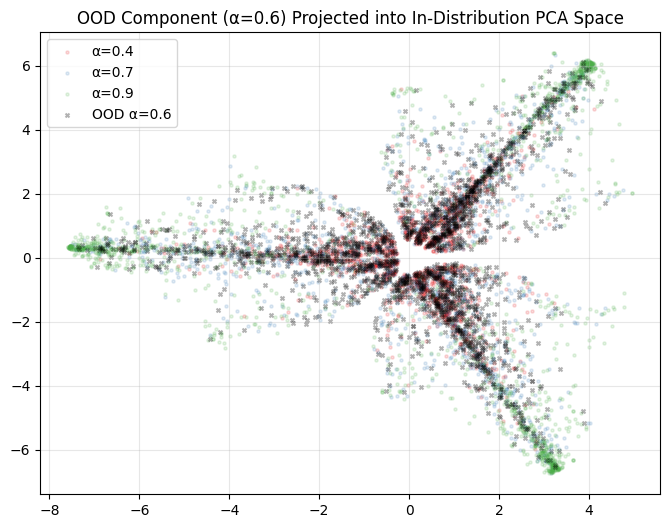

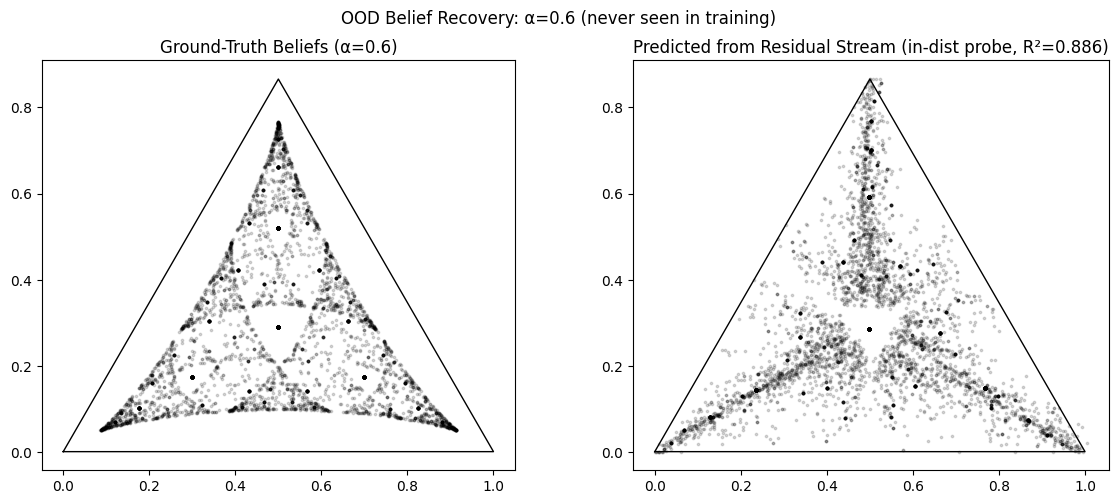

In [22]:
def ood_generalization(model, dataset, ood_alpha=0.6, n_sequences=2000, bos_token=3):
    """Test model on sequences from an unseen component."""
    model.eval()
    model.to(device)

    # Generate OOD sequences
    ood_comp = Mess3(alpha=ood_alpha, x=dataset.x)
    ood_tokens, ood_beliefs = [], []
    for _ in range(n_sequences):
        tokens, _ = ood_comp.generate_sequence(dataset.seq_len)
        beliefs = ood_comp.compute_belief_states(tokens)
        ood_tokens.append(tokens)
        ood_beliefs.append(beliefs)
    ood_tokens = torch.tensor(np.array(ood_tokens), dtype=torch.long)
    ood_beliefs = np.array(ood_beliefs)

    # Extract activations for OOD sequences
    bos = torch.full((n_sequences, 1), bos_token, dtype=torch.long)
    input_seq = torch.cat([bos, ood_tokens], dim=1).to(device)
    with torch.no_grad():
        logits_ood, acts_ood = model(input_seq[:, :-1], return_activations=True)

    ood_acts = acts_ood['ln_f'].numpy()  # (N, T, D)
    N, T, D = ood_acts.shape

    # OOD loss
    targets = input_seq[:, 1:]
    ood_loss = F.cross_entropy(logits_ood.reshape(-1, logits_ood.size(-1)),
                               targets.reshape(-1)).item()

    # 1. Probe trained on IN-distribution data, tested on OOD
    in_acts = data['ln_f'].reshape(-1, D)
    in_beliefs = data['beliefs'].reshape(-1, 3)
    probe_in = Ridge(alpha=1.0).fit(in_acts, in_beliefs)

    ood_acts_flat = ood_acts.reshape(-1, D)
    ood_beliefs_flat = ood_beliefs.reshape(-1, 3)
    r2_transfer = probe_in.score(ood_acts_flat, ood_beliefs_flat)

    # 2. Probe trained directly on OOD data (ceiling)
    Xtr, Xte, ytr, yte = train_test_split(ood_acts_flat, ood_beliefs_flat,
                                           test_size=0.3, random_state=42)
    r2_direct = Ridge(alpha=1.0).fit(Xtr, ytr).score(Xte, yte)

    print(f'OOD component: \u03b1={ood_alpha}')
    print(f'OOD model loss:            {ood_loss:.4f} (trained components avg: {np.mean(losses[-100:]):.4f})')
    print(f'Belief R\u00b2 (in-dist probe):  {r2_transfer:.4f}')
    print(f'Belief R\u00b2 (OOD-trained):    {r2_direct:.4f}')
    print(f'Transfer gap:              {r2_direct - r2_transfer:.4f}')

    # 3. Visualize OOD in same PCA space as in-distribution
    in_labels = data['comp_labels']
    all_in = data['ln_f'][:, -1, :]  # last position
    ood_last = ood_acts[:, -1, :]  # last position

    pca = PCA(n_components=2)
    in_coords = pca.fit_transform(all_in)  # fit on in-distribution
    ood_coords = pca.transform(ood_last)    # project OOD into same space

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    names = ['\u03b1=0.4', '\u03b1=0.7', '\u03b1=0.9']
    for c in range(3):
        mask = in_labels == c
        ax.scatter(in_coords[mask, 0], in_coords[mask, 1],
                   c=colors[c], label=names[c], alpha=0.15, s=5)
    ax.scatter(ood_coords[:, 0], ood_coords[:, 1],
               c='black', label=f'OOD \u03b1={ood_alpha}', alpha=0.3, s=8, marker='x')
    ax.set_title(f'OOD Component (\u03b1={ood_alpha}) Projected into In-Distribution PCA Space')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(f'{RESULTS_DIR}/ood_generalization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Belief simplex for OOD
    pred_ood = probe_in.predict(ood_acts_flat)
    gt_cart = bary_to_cart(ood_beliefs_flat)
    pred_cart = bary_to_cart(np.clip(pred_ood, 0, 1))
    tri = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])

    sub = np.random.choice(len(gt_cart), min(5000, len(gt_cart)), replace=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(gt_cart[sub, 0], gt_cart[sub, 1], c='black', alpha=0.15, s=3)
    axes[0].plot(tri[:,0], tri[:,1], 'k-', lw=1)
    axes[0].set_title(f'Ground-Truth Beliefs (\u03b1={ood_alpha})')
    axes[0].set_aspect('equal')
    axes[1].scatter(pred_cart[sub, 0], pred_cart[sub, 1], c='black', alpha=0.15, s=3)
    axes[1].plot(tri[:,0], tri[:,1], 'k-', lw=1)
    axes[1].set_title(f'Predicted from Residual Stream (in-dist probe, R\u00b2={r2_transfer:.3f})')
    axes[1].set_aspect('equal')
    plt.suptitle(f'OOD Belief Recovery: \u03b1={ood_alpha} (never seen in training)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/ood_belief_simplex.png', dpi=150, bbox_inches='tight')
    plt.show()

    return r2_transfer, r2_direct, ood_loss


r2_ood_transfer, r2_ood_direct, ood_loss = ood_generalization(model, dataset)